# Standard QSAR baseline comparison

**Question** — "Is the Graphormer embedding + domain adaptation framework actually better than plain QSAR?"

A question reviewers will certainly ask. It uses the same scaffold 5-fold and the same target split, so
it compares directly with the results of 01–14.

## Comparison axes

**Molecular representation** — separates whether performance comes from the representation or the model
- `ECFP4` : Morgan radius 2, 2048 bits
- `RDKit` : all RDKit descriptors (standardised)
- `Graphormer` : the 768-d embedding of this study

**Models**
- `RF` : XGBoost random-forest mode (`XGBRFRegressor`, GPU)
- `XGB` : gradient boosting (GPU)
- `Ridge` : linear (CPU — already a few ms)

**Training settings**
- `target-only` : target train only — same condition as the 01 baseline
- `pooled` : source + target merged without domain distinction — the simplest transfer

> **GPU note:** RF and XGB run with `device='cuda'`. Handling 2048-d ECFP on an 8 GB GPU
> requires limiting tree depth and histogram bins (`max_depth` 8, `max_bin` 64) — the defaults
> request 16 GB and run out of memory. sklearn RandomForest does not support GPUs
> (cuML not installed), so XGBoost's RF mode was used instead. RDKit descriptor computation is CPU-only, but
> it is **cached per molecule**, so it is computed only once overall.

In [1]:
import os
import sys
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, rdFingerprintGenerator
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor, XGBRFRegressor

warnings.filterwarnings('ignore')
RDLogger.DisableLog('rdApp.*')

ROOT = r'..'
DATA_DIR = os.path.join(ROOT, 'data', 'cv_datasets')
OUT_DIR = os.path.join(ROOT, 'results', 'qsar_baselines')
os.makedirs(OUT_DIR, exist_ok=True)

PROPERTIES = ['fu', 'clearance', 'half_life']
LABEL = {'fu': 'f_u', 'clearance': 'CL', 'half_life': 't½'}
N_FOLDS, SEEDS = 5, [0, 1, 2]
MAX_SOURCE = 20000          # cap on source size for pooled training
REPS = ['ECFP4', 'RDKit', 'Graphormer']
MODELS = ['RF', 'XGB', 'Ridge']

try:                        # check for GPU
    import torch
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
except ImportError:
    DEVICE = 'cpu'
print('xgboost device:', DEVICE)

_fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
_e = np.load(os.path.join(ROOT, 'features', 'graphormer_cv_embeddings.npz'), allow_pickle=True)
_X, _K = _e['X'], _e['keys']
SMILES_TO_EMB = {s: _X[i] for i, s in enumerate(_K)}
_DESC = list(Descriptors.descList)
print(f'{len(SMILES_TO_EMB)} embeddings | {len(_DESC)} RDKit descriptors')

pd.set_option('display.width', 220)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': '#e6e5e0', 'grid.linewidth': 0.6, 'axes.axisbelow': True})

xgboost device: cuda
embeddings: 58304 | RDKit descriptors: 210


## 1. Compute representations (per-molecule cache)

The source is identical in every fold, and the target overlaps heavily across folds.
A per-molecule cache computes each molecule only once — without it, recomputing descriptors alone would take hours.

In [2]:
_cache = {}


def _one(smi, kind):
    key = (smi, kind)
    if key not in _cache:
        m = Chem.MolFromSmiles(str(smi))
        if kind == 'ECFP4':
            v = np.asarray(_fpgen.GetFingerprint(m), dtype='float32')
        else:
            v = []
            for _, fn in _DESC:
                try:
                    v.append(fn(m))
                except Exception:
                    v.append(np.nan)
            v = np.asarray(v, dtype='float32')
        _cache[key] = np.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0)
    return _cache[key]


def featurize(smiles, kind):
    if kind == 'Graphormer':
        return np.stack([SMILES_TO_EMB[s] for s in smiles]).astype('float32')
    return np.vstack([_one(s, kind) for s in smiles])


def load_split(prop, fold, split):
    f = 'source' if split == 'source' else f'target_{split}'
    df = pd.read_csv(os.path.join(DATA_DIR, f'fold_{fold}', f'{prop}_{f}.csv'), low_memory=False)
    keep = [(s, v) for s, v in zip(df['smiles'].astype(str), df['value']) if s in SMILES_TO_EMB]
    return [s for s, _ in keep], np.array([v for _, v in keep], dtype='float32')


# Fill the cache with every unique SMILES up front (kept separate so progress is visible)
t0 = time.time()
all_smiles = set()
for prop in PROPERTIES:
    for fold in range(N_FOLDS):
        for sp in ('train', 'test', 'source'):
            all_smiles |= set(load_split(prop, fold, sp)[0])
all_smiles = sorted(all_smiles)
print(f'{len(all_smiles)} unique molecules — computing descriptors...')
for i, s in enumerate(all_smiles):
    _one(s, 'ECFP4'); _one(s, 'RDKit')
    if (i + 1) % 5000 == 0:
        print(f'  {i+1}/{len(all_smiles)}  ({time.time()-t0:.0f}s)', flush=True)
print(f'Done ({time.time()-t0:.0f}s)')

unique molecules: 24407 — computing descriptors...
  5000/24407  (59s)
  10000/24407  (118s)
  15000/24407  (176s)
  20000/24407  (232s)
Done (281s)


## 2. Training and evaluation

`RF` and `XGB` run on the GPU, `Ridge` on the CPU.
`Ridge` is deterministic, so it runs with a single seed.

In [3]:
def make_model(name, seed):
    if name == 'RF':
        return XGBRFRegressor(n_estimators=300, max_depth=8, max_bin=64, subsample=0.8,
                              colsample_bynode=0.3, random_state=seed, device=DEVICE,
                              tree_method='hist', verbosity=0)
    if name == 'XGB':
        return XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, max_bin=64,
                            subsample=0.8, colsample_bytree=0.8, random_state=seed, device=DEVICE,
                            tree_method='hist', verbosity=0)
    return Ridge(alpha=1.0)


def metrics(y, p):
    p = np.nan_to_num(np.asarray(p, dtype='float64'), nan=0.0, posinf=1e6, neginf=-1e6)
    return {'r2': float(r2_score(y, p)), 'rho': float(spearmanr(y, p)[0]),
            'rmse': float(np.sqrt(np.mean((y - p) ** 2))), 'mae': float(np.mean(np.abs(y - p)))}


rows, t0 = [], time.time()
for prop in PROPERTIES:
    for fold in range(N_FOLDS):
        tr_s, tr_y = load_split(prop, fold, 'train')
        te_s, te_y = load_split(prop, fold, 'test')
        sr_s, sr_y = load_split(prop, fold, 'source')
        if len(sr_s) > MAX_SOURCE:
            idx = np.random.RandomState(0).choice(len(sr_s), MAX_SOURCE, replace=False)
            sr_s, sr_y = [sr_s[i] for i in idx], sr_y[idx]

        for rep in REPS:
            Xtr, Xte, Xsr = (featurize(x, rep) for x in (tr_s, te_s, sr_s))
            if rep == 'RDKit':                       # descriptors differ widely in scale, so standardise
                sc = StandardScaler().fit(np.vstack([Xtr, Xsr]))
                Xtr, Xte, Xsr = sc.transform(Xtr), sc.transform(Xte), sc.transform(Xsr)
            for mdl in MODELS:
                for setting in ('target-only', 'pooled'):
                    X = Xtr if setting == 'target-only' else np.vstack([Xtr, Xsr])
                    y = tr_y if setting == 'target-only' else np.r_[tr_y, sr_y]
                    for seed in SEEDS:
                        if mdl == 'Ridge' and seed > 0:
                            continue
                        m = make_model(mdl, seed).fit(X, y)
                        rows.append({'property': prop, 'fold': fold, 'rep': rep, 'model': mdl,
                                     'setting': setting, 'seed': seed, 'n_train': len(X),
                                     **metrics(te_y, m.predict(Xte))})
        pd.DataFrame(rows).to_csv(os.path.join(OUT_DIR, 'runs.csv'), index=False)
        print(f'  {prop:<10} fold {fold}  ({time.time()-t0:.0f}s)', flush=True)

runs = pd.DataFrame(rows)
print(f'\nTotal {time.time()-t0:.0f}s,  {len(runs)} runs')

  fu         fold 0  (141s)
  fu         fold 1  (278s)
  fu         fold 2  (417s)
  fu         fold 3  (561s)
  fu         fold 4  (705s)
  clearance  fold 0  (849s)
  clearance  fold 1  (994s)
  clearance  fold 2  (1139s)
  clearance  fold 3  (1281s)
  clearance  fold 4  (1432s)
  half_life  fold 0  (1580s)
  half_life  fold 1  (1733s)
  half_life  fold 2  (1880s)
  half_life  fold 3  (2025s)
  half_life  fold 4  (2172s)

Total 2172s,  630 runs


## 3. Results — representation × model × setting

In [4]:
summ = runs.groupby(['property', 'rep', 'model', 'setting'])[['r2', 'rho', 'rmse', 'mae']].mean()
summ.to_csv(os.path.join(OUT_DIR, 'summary.csv'), encoding='utf-8-sig')
summ.round(4).unstack('property')['r2'][[p for p in PROPERTIES]].rename(columns=LABEL)

property                         f_u      CL      t½
rep        model setting                            
ECFP4      RF    pooled       0.1707  0.0151  0.0124
                 target-only  0.2935  0.0605  0.1215
           Ridge pooled      -0.5887 -0.4142 -0.5072
                 target-only  0.2772 -0.2154 -0.2550
           XGB   pooled       0.3226  0.0367  0.0812
                 target-only  0.3056  0.0738  0.1602
Graphormer RF    pooled       0.2407  0.0282  0.0593
                 target-only  0.2843  0.1436  0.1434
           Ridge pooled      -0.0226 -0.0847 -0.2327
                 target-only -0.8312 -0.5312 -0.5550
           XGB   pooled       0.2908  0.0474  0.0834
                 target-only  0.2684  0.1347  0.1441
RDKit      RF    pooled       0.3881  0.0576  0.0758
                 target-only  0.4427  0.1696  0.2228
           Ridge pooled       0.2240 -0.0950 -0.1058
                 target-only -0.1800 -0.1643 -0.0007
           XGB   pooled       0.4238  0.1048  0.1528
                 target-only  0.4382  0.1947  0.2372

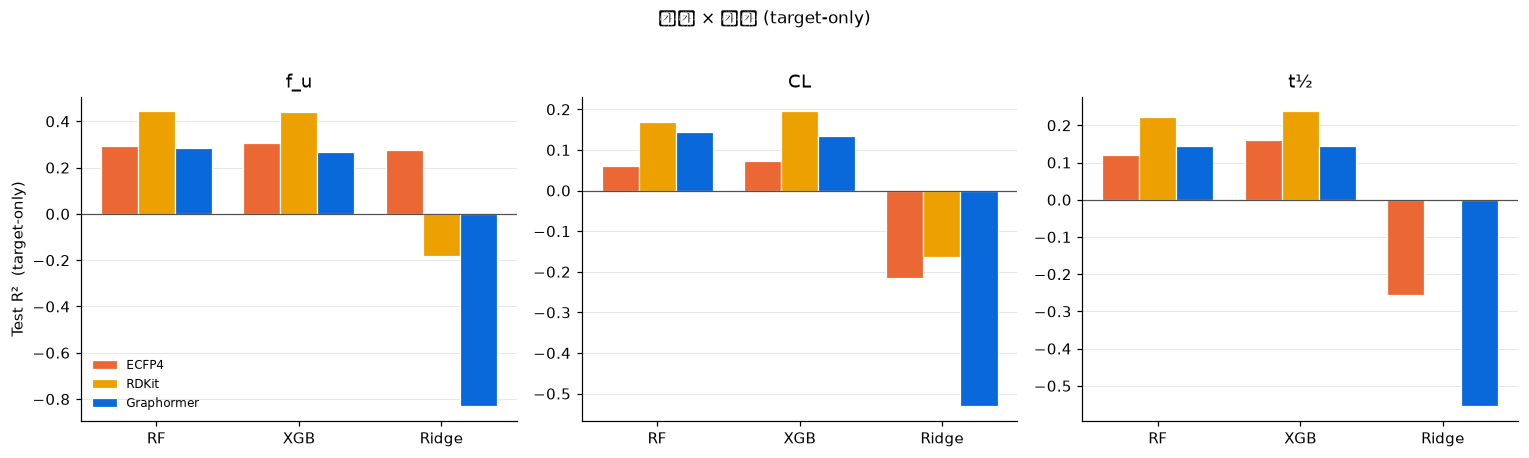

In [5]:
fig, axes = plt.subplots(1, len(PROPERTIES), figsize=(14, 4), sharey=False)
colors = {'ECFP4': '#eb6834', 'RDKit': '#eda100', 'Graphormer': '#0969da'}
for ax, prop in zip(axes, PROPERTIES):
    d = runs[(runs.property == prop) & (runs.setting == 'target-only')]
    g = d.groupby(['rep', 'model']).r2.mean().unstack('model')[MODELS]
    x = np.arange(len(MODELS)); w = 0.26
    for i, rep in enumerate(REPS):
        ax.bar(x + (i - 1) * w, g.loc[rep], width=w, color=colors[rep], edgecolor='white',
               linewidth=0.8, label=rep if ax is axes[0] else None)
    ax.set_xticks(x); ax.set_xticklabels(MODELS)
    ax.set_title(LABEL[prop]); ax.grid(axis='x', visible=False)
    ax.axhline(0, color='#52514e', lw=0.8)
axes[0].set_ylabel('Test R²  (target-only)')
axes[0].legend(fontsize=8, frameon=False)
fig.suptitle('Representation × model (target-only)', fontsize=11, y=1.03)
plt.tight_layout(); plt.show()

## 4. Comparison with this study

Places the strongest QSAR baseline on the same axis as the models of this study.

- `QSAR best (target-only)` : best of the combinations above
- `QSAR best (pooled)` : best when the source is simply merged — **transfer without regard to domain**
- `Graphormer+MLP` : 01 baseline (10-seed value from 08)
- `pretrain → FT` : notebook 10 (upper Graphormer layers pretrained on in vitro labels)

In [6]:
rows_c = []
for prop in PROPERTIES:
    d = runs[runs.property == prop]
    for setting in ('target-only', 'pooled'):
        g = d[d.setting == setting].groupby(['rep', 'model']).r2.mean()
        rep, mdl = g.idxmax()
        rows_c.append({'property': LABEL[prop], 'model': f'QSAR best ({setting})',
                       'detail': f'{rep} + {mdl}', 'R²': g.max()})

sig_dir = os.path.join(ROOT, 'results', 'significance_mae')
if not os.path.exists(os.path.join(sig_dir, 'runs.csv')):
    sig_dir = os.path.join(ROOT, 'results', 'significance')
sig = pd.read_csv(os.path.join(sig_dir, 'runs.csv'))
for prop in PROPERTIES:
    v = sig[(sig.method == 'Baseline') & (sig.property == prop)].r2.mean()
    rows_c.append({'property': LABEL[prop], 'model': 'Graphormer + MLP', 'detail': '01 baseline (10 seeds)', 'R²': v})

pre = os.path.join(ROOT, 'results', 'pretrain_ft', 'runs.csv')
if os.path.exists(pre):
    pf = pd.read_csv(pre)
    for prop in PROPERTIES:
        v = pf[pf.property == prop].r2.mean()
        rows_c.append({'property': LABEL[prop], 'model': 'pretrain → FT', 'detail': 'notebook 10 (seeds 0–2)', 'R²': v})

comp = pd.DataFrame(rows_c)
display(comp.pivot(index=['model', 'detail'], columns='property', values='R²')[
    [LABEL[p] for p in PROPERTIES]].round(4))

property                                           f_u      CL      t½
model                   detail                                        
Graphormer + MLP        01 baseline (10 seeds)  0.2522  0.0969  0.0838
QSAR best (pooled)      RDKit + XGB             0.4238  0.1048  0.1528
QSAR best (target-only) RDKit + RF              0.4427     NaN     NaN
                        RDKit + XGB                NaN  0.1947  0.2372
pretrain → FT           notebook 10 (seeds 0–2)       0.3450  0.1186  0.1470

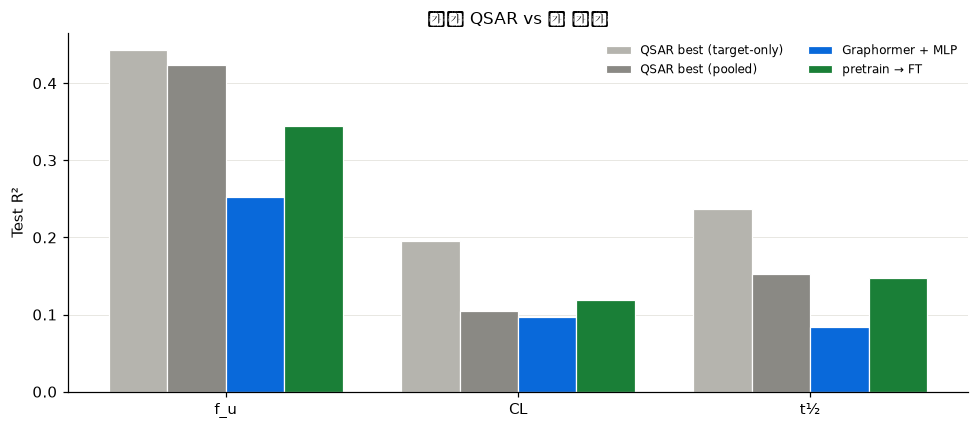

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
order = comp['model'].drop_duplicates().tolist()
x = np.arange(len(PROPERTIES)); w = 0.8 / len(order)
pal = ['#b5b4ae', '#8a8984', '#0969da', '#1a7f37']
for i, m in enumerate(order):
    vals = [comp[(comp.model == m) & (comp.property == LABEL[p])]['R²'].mean() for p in PROPERTIES]
    ax.bar(x + (i - (len(order) - 1) / 2) * w, vals, width=w, label=m,
           color=pal[i % len(pal)], edgecolor='white', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels([LABEL[p] for p in PROPERTIES])
ax.set_ylabel('Test R²'); ax.grid(axis='x', visible=False)
ax.legend(fontsize=8, frameon=False, ncol=2)
ax.set_title('Standard QSAR vs this study', fontsize=11)
plt.tight_layout(); plt.show()

## 5. Caveats for interpretation

1. **Different numbers of seeds** — QSAR uses 3 seeds (Ridge 1), the 08 baseline 10 seeds.
   Keep seed variation (R² SD ≈ 0.035 on f_u) in mind when comparing absolute values.
2. **No hyperparameter tuning** — the QSAR side uses conventional defaults.
   So read it as a lower bound ("QSAR does at least this well"); tuning could raise it.
3. **pooled is a deliberately simple comparison** — a setting that merges the data with no regard to the domain difference,
   used as the reference that DA methods should beat.
4. **RF is XGBoost's RF mode, not sklearn** — chosen to use the GPU;
   results are not exactly identical to sklearn RandomForest.